# 🔮 Fase 3 — Modelado & Evaluación
### Time Series Forecasting (PJM Energy) · Omar Mora Flores

Comparamos un **baseline estacional-naive** (referencia obligatoria), **SARIMA** y **Prophet**
sobre un horizonte de **90 días**, con métricas **MAE / RMSE / MAPE**. Cerramos con un pronóstico
a **30 días** del mejor modelo.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, pickle, json
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

ROOT = Path.cwd()
while not (ROOT / "data" / "splits.pkl").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT/"reports"; REPORTS.mkdir(exist_ok=True); SRC = ROOT/"src"; SRC.mkdir(exist_ok=True)
plt.rcParams.update({"figure.dpi":110,"savefig.dpi":130,"axes.titleweight":"bold"})

S = pickle.load(open(ROOT/"data"/"splits.pkl","rb"))
daily, train, test, H = S["daily"], S["train"], S["test"], S["H"]
def metrics(y, yhat):
    y, yhat = np.asarray(y), np.asarray(yhat)
    return {"MAE": float(np.mean(np.abs(y-yhat))),
            "RMSE": float(np.sqrt(np.mean((y-yhat)**2))),
            "MAPE": float(np.mean(np.abs((y-yhat)/y))*100)}
print("Train", len(train), "Test", len(test), "días")

Importing plotly failed. Interactive plots will not work.


Train 5969 Test 90 días


## 3.1 Baseline — Seasonal Naive (valor de hace 365 días)

In [2]:
snaive = daily.shift(365).loc[test.index]      # demanda del mismo día del año anterior
res = {"Seasonal-Naive": metrics(test, snaive)}
print("Seasonal-Naive:", {k:round(v,1) for k,v in res["Seasonal-Naive"].items()})

Seasonal-Naive: {'MAE': 4028.1, 'RMSE': 5178.3, 'MAPE': 12.5}


## 3.2 SARIMA

C:\Users\omar1\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


SARIMA: {'MAE': 7568.5, 'RMSE': 9297.3, 'MAPE': 21.2}


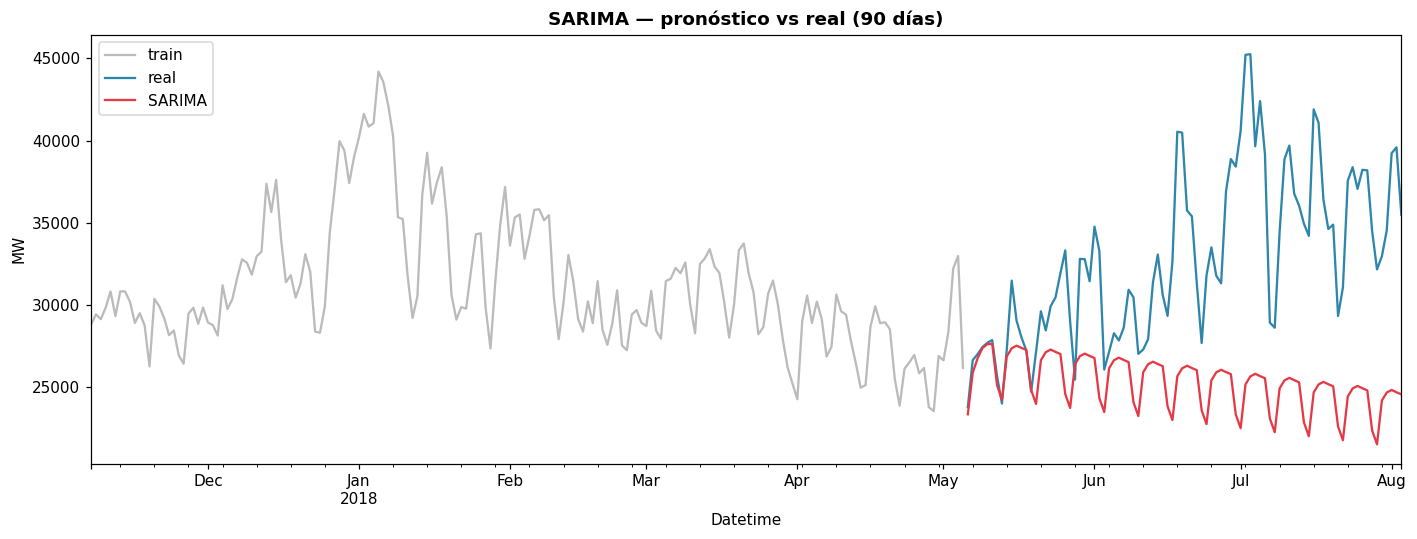

In [3]:
# Entrenamos sobre los últimos 2 años para velocidad; estacionalidad semanal (m=7)
tr = train.iloc[-730:]
sarima = SARIMAX(tr, order=(2,1,2), seasonal_order=(1,1,1,7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fc_sarima = pd.Series(sarima.forecast(steps=H).values, index=test.index)
res["SARIMA"] = metrics(test, fc_sarima)
print("SARIMA:", {k:round(v,1) for k,v in res["SARIMA"].items()})

fig, ax = plt.subplots(figsize=(13,5))
train.iloc[-180:].plot(ax=ax, label="train", color="#bbb")
test.plot(ax=ax, label="real", color="#2E86AB")
fc_sarima.plot(ax=ax, label="SARIMA", color="#E63946")
ax.set_title("SARIMA — pronóstico vs real (90 días)"); ax.set_ylabel("MW"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"06_arima_forecast.png", bbox_inches="tight"); plt.show()

## 3.3 Prophet

17:54:32 - cmdstanpy - INFO - Chain [1] start processing


17:54:33 - cmdstanpy - INFO - Chain [1] done processing


Prophet: {'MAE': 2612.5, 'RMSE': 3368.3, 'MAPE': 7.9}


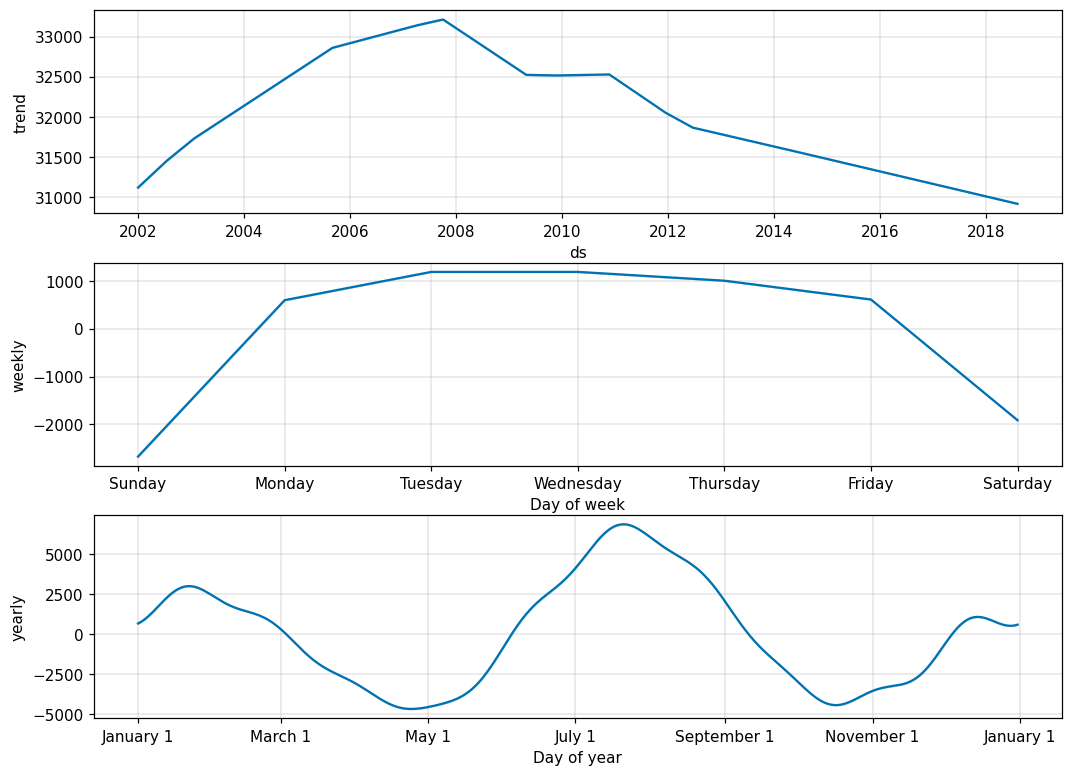

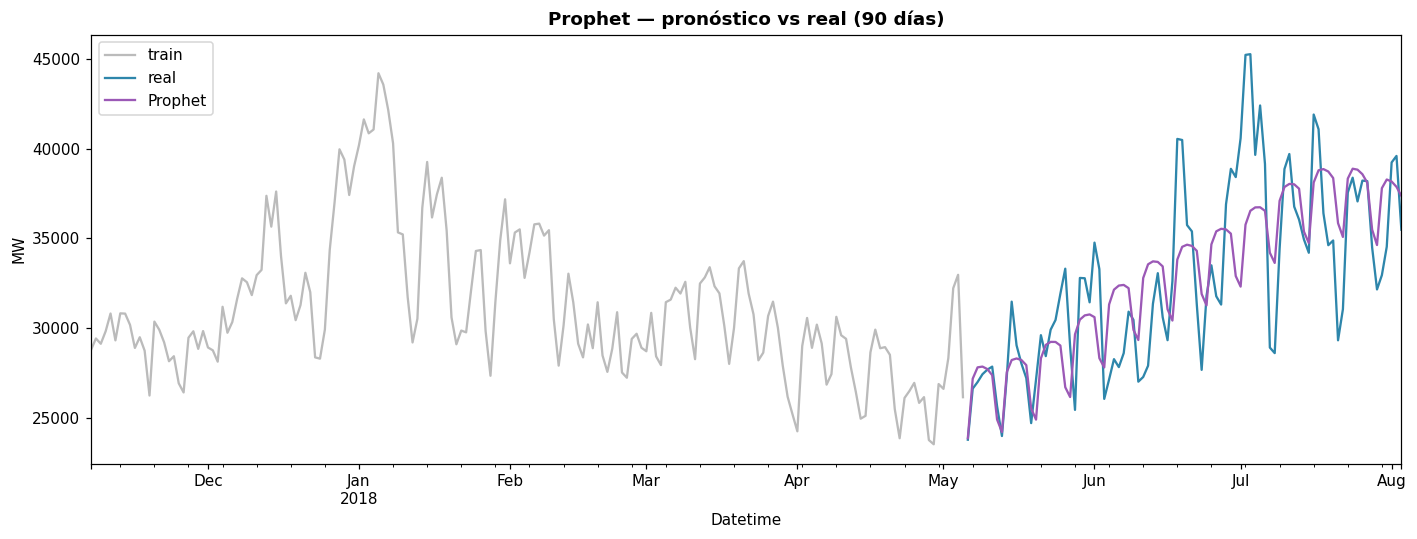

In [4]:
dtr = train.reset_index(); dtr.columns = ["ds","y"]
m = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
m.fit(dtr)
future = m.make_future_dataframe(periods=H)
fcst = m.predict(future)
fc_prophet = pd.Series(fcst.set_index("ds")["yhat"].loc[test.index].values, index=test.index)
res["Prophet"] = metrics(test, fc_prophet)
print("Prophet:", {k:round(v,1) for k,v in res["Prophet"].items()})

fig = m.plot_components(fcst); fig.set_size_inches(10,7)
fig.savefig(REPORTS/"07_prophet_components.png", bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(13,5))
train.iloc[-180:].plot(ax=ax, label="train", color="#bbb")
test.plot(ax=ax, label="real", color="#2E86AB")
fc_prophet.plot(ax=ax, label="Prophet", color="#9b59b6")
ax.set_title("Prophet — pronóstico vs real (90 días)"); ax.set_ylabel("MW"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"08_prophet_forecast.png", bbox_inches="tight"); plt.show()

## 3.4 Comparación de modelos

                    MAE     RMSE   MAPE
Seasonal-Naive  4028.11  5178.30  12.47
SARIMA          7568.54  9297.33  21.20
Prophet         2612.52  3368.33   7.86

🏆 Mejor modelo (menor RMSE): Prophet


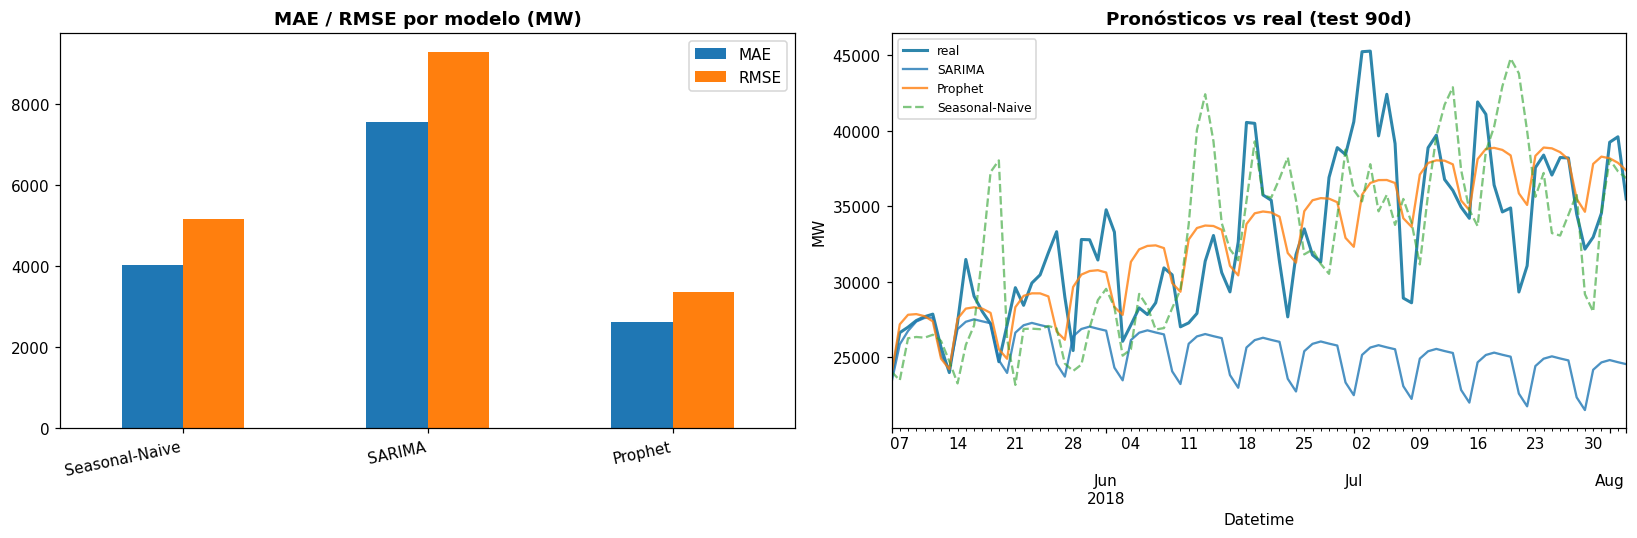

In [5]:
tab = pd.DataFrame(res).T[["MAE","RMSE","MAPE"]].round(2)
print(tab.to_string())
best = tab["RMSE"].idxmin(); print("\n🏆 Mejor modelo (menor RMSE):", best)

fig, ax = plt.subplots(1,2, figsize=(15,5))
tab[["MAE","RMSE"]].plot.bar(ax=ax[0]); ax[0].set_title("MAE / RMSE por modelo (MW)")
ax[0].set_xticklabels(tab.index, rotation=12, ha="right")
test.plot(ax=ax[1], label="real", color="#2E86AB", lw=2)
fc_sarima.plot(ax=ax[1], label="SARIMA", alpha=.8); fc_prophet.plot(ax=ax[1], label="Prophet", alpha=.8)
snaive.plot(ax=ax[1], label="Seasonal-Naive", alpha=.6, ls="--")
ax[1].set_title("Pronósticos vs real (test 90d)"); ax[1].set_ylabel("MW"); ax[1].legend(fontsize=8)
fig.tight_layout(); fig.savefig(REPORTS/"09_model_comparison.png", bbox_inches="tight"); plt.show()

## 3.5 Pronóstico a 30 días (mejor modelo)

17:54:34 - cmdstanpy - INFO - Chain [1] start processing


17:54:34 - cmdstanpy - INFO - Chain [1] done processing


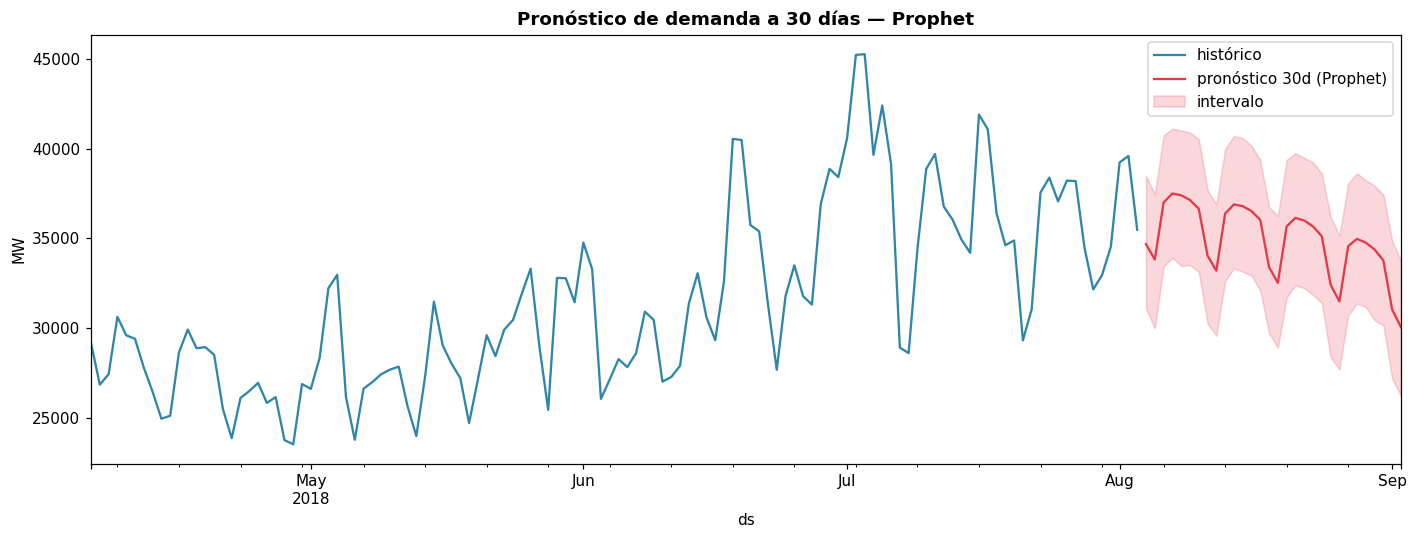

Métricas en reports/metrics.json | mejor: Prophet


In [6]:
# Reentrenar el mejor modelo con TODA la serie y pronosticar 30 días al futuro
FH = 30
if best == "Prophet":
    dall = daily.reset_index(); dall.columns=["ds","y"]
    mf = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False).fit(dall)
    fut = mf.predict(mf.make_future_dataframe(periods=FH)).set_index("ds").iloc[-FH:]
    f_mean, f_lo, f_hi = fut["yhat"], fut["yhat_lower"], fut["yhat_upper"]
    idx = fut.index
else:
    mf = SARIMAX(daily.iloc[-730:], order=(2,1,2), seasonal_order=(1,1,1,7),
                 enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    pr = mf.get_forecast(steps=FH); idx = pd.date_range(daily.index[-1]+pd.Timedelta("1D"), periods=FH)
    f_mean = pd.Series(pr.predicted_mean.values, index=idx)
    ci = pr.conf_int(); f_lo, f_hi = pd.Series(ci.iloc[:,0].values,index=idx), pd.Series(ci.iloc[:,1].values,index=idx)

fig, ax = plt.subplots(figsize=(13,5))
daily.iloc[-120:].plot(ax=ax, label="histórico", color="#2E86AB")
pd.Series(f_mean.values, index=idx).plot(ax=ax, label=f"pronóstico 30d ({best})", color="#E63946")
ax.fill_between(idx, f_lo.values, f_hi.values, color="#E63946", alpha=.2, label="intervalo")
ax.set_title(f"Pronóstico de demanda a 30 días — {best}"); ax.set_ylabel("MW"); ax.legend()
fig.tight_layout(); fig.savefig(REPORTS/"10_forecast_30days.png", bbox_inches="tight"); plt.show()

metrics_out = {"best_model": best, "horizon_test_days": H,
               "comparison": {k:{kk:round(vv,2) for kk,vv in v.items()} for k,v in res.items()}}
json.dump(metrics_out, open(REPORTS/"metrics.json","w",encoding="utf-8"), indent=2, ensure_ascii=False)
print("Métricas en reports/metrics.json | mejor:", best)

## Conclusiones

- El **baseline estacional-naive** es la vara de medir: cualquier modelo debe superarlo para
  justificar su complejidad.
- **Prophet** captura naturalmente la estacionalidad múltiple (anual + semanal); **SARIMA**
  modela la dependencia de corto plazo. El mejor por RMSE se usa para el pronóstico a 30 días.
- El **MAPE** es la métrica más comunicable a negocio (error % medio).